In [ ]:
# Bank loan Approved or Rejected

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

C:\Users\SIDDHU\AppData\Local\Temp\ipykernel_19868\3060795443.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method = 'ffill', inplace = True)


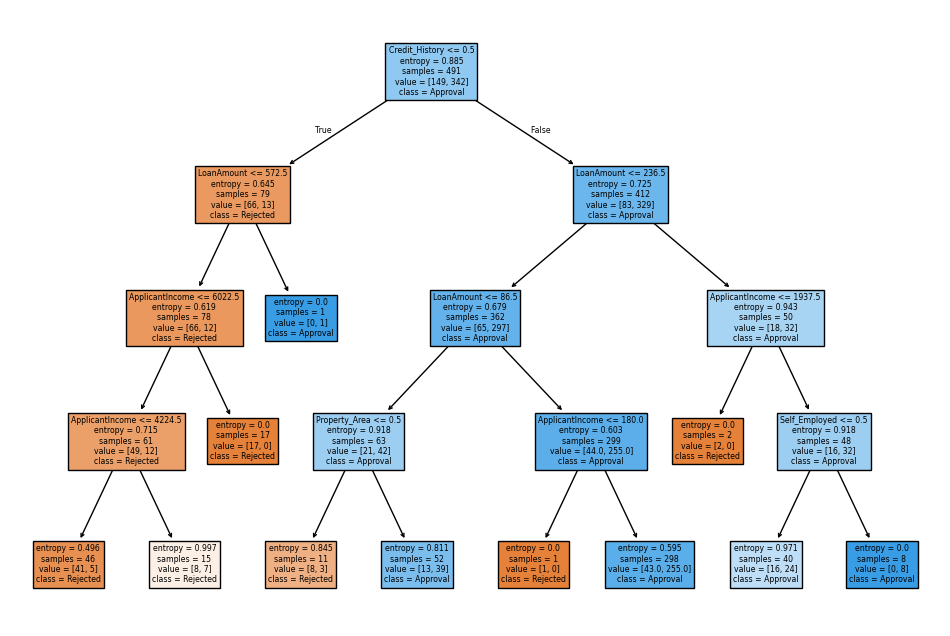

|--- Credit_History <= 0.50
|   |--- LoanAmount <= 572.50
|   |   |--- ApplicantIncome <= 6022.50
|   |   |   |--- ApplicantIncome <= 4224.50
|   |   |   |   |--- class: 0
|   |   |   |--- ApplicantIncome >  4224.50
|   |   |   |   |--- class: 0
|   |   |--- ApplicantIncome >  6022.50
|   |   |   |--- class: 0
|   |--- LoanAmount >  572.50
|   |   |--- class: 1
|--- Credit_History >  0.50
|   |--- LoanAmount <= 236.50
|   |   |--- LoanAmount <= 86.50
|   |   |   |--- Property_Area <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Property_Area >  0.50
|   |   |   |   |--- class: 1
|   |   |--- LoanAmount >  86.50
|   |   |   |--- ApplicantIncome <= 180.00
|   |   |   |   |--- class: 0
|   |   |   |--- ApplicantIncome >  180.00
|   |   |   |   |--- class: 1
|   |--- LoanAmount >  236.50
|   |   |--- ApplicantIncome <= 1937.50
|   |   |   |--- class: 0
|   |   |--- ApplicantIncome >  1937.50
|   |   |   |--- Self_Employed <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Self_E

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier,export_text, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

# explore data

print(data.head())
print(data.info())

# handle missing value 

data.fillna(method = 'ffill', inplace = True)

# convert the text data in numical label using Label Encoder

Label_Encoder = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column]=le.fit_transform(data[column].astype(str))
    Label_Encoder[column] = le

# Define features and target
 
x = data[["ApplicantIncome", "Credit_History", "LoanAmount", "Self_Employed", "Property_Area"]]
y = data["Loan_Status"]

# train_test_split the data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =42)

# Train Decision tree

model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 4 , random_state = 42)
model.fit(x_train, y_train)

# prediction

pred = model.predict(x_test)

# Elevation

print("loan_approved= 1->yes, 0->No :", pred)
print("accuracy_score:\n", accuracy_score(y_test, pred))

# visulizaation

plt.figure(figsize = (12, 8))
plot_tree(model, feature_names=x.columns, class_names = ['Rejected', 'Approval'], filled=True)
plt.show()

# show text

tree_rules = export_text(model, feature_names=list(x.columns))
print(tree_rules)


In [ ]:
# Customer Churn Prediction (Telecom / SaaS)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

C:\Users\SIDDHU\AppData\Local\Temp\ipykernel_8468\1414908866.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method = 'ffill', inplace = True)


chunk prediction, 1->leave, 0->stay : [0 0 0 ... 0 0 0]
accuracy_score:
 0.779460482725982
confusion_matrix:
 [[1439  100]
 [ 366  208]]
classifiaction_report:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86      1539
           1       0.68      0.36      0.47       574

    accuracy                           0.78      2113
   macro avg       0.74      0.65      0.67      2113
weighted avg       0.76      0.78      0.75      2113



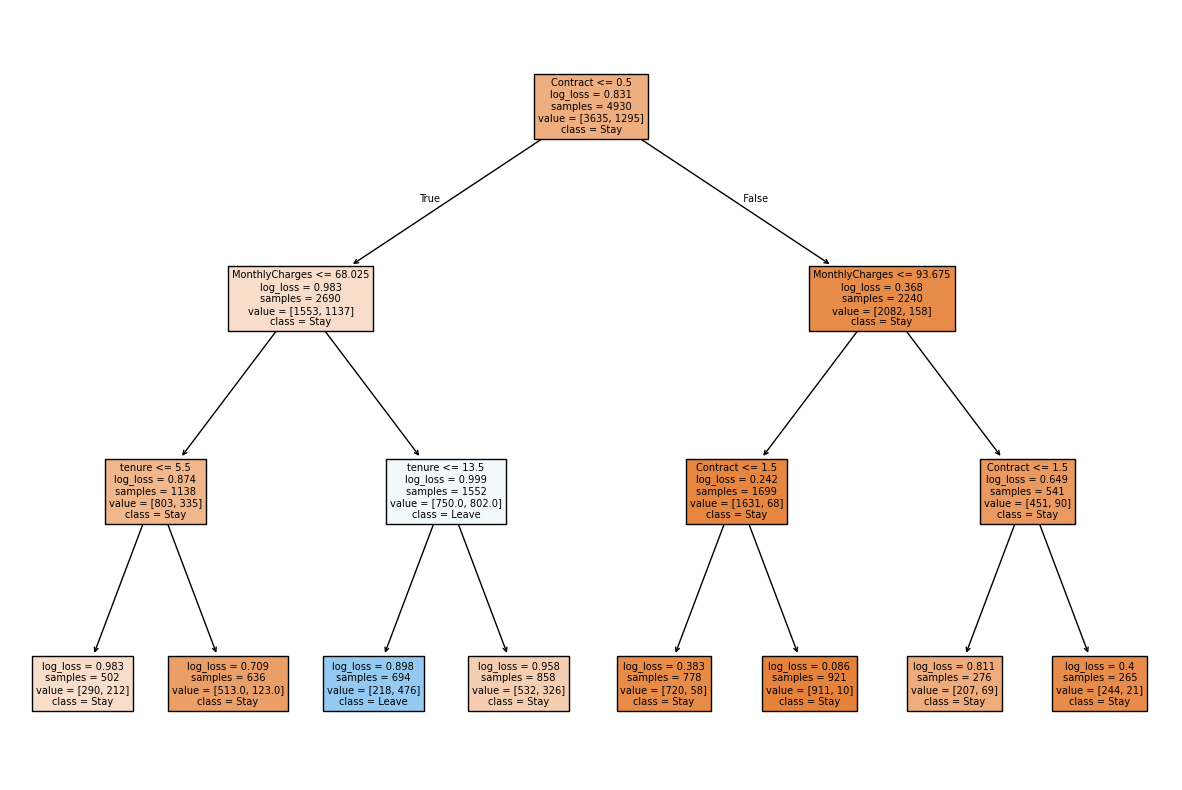

|--- Contract <= 0.50
|   |--- MonthlyCharges <= 68.03
|   |   |--- tenure <= 5.50
|   |   |   |--- class: 0
|   |   |--- tenure >  5.50
|   |   |   |--- class: 0
|   |--- MonthlyCharges >  68.03
|   |   |--- tenure <= 13.50
|   |   |   |--- class: 1
|   |   |--- tenure >  13.50
|   |   |   |--- class: 0
|--- Contract >  0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- class: 0
|   |   |--- Contract >  1.50
|   |   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- class: 0
|   |   |--- Contract >  1.50
|   |   |   |--- class: 0



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn. model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# upload and load dataset

data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(data.head())
print(data.info())

# Handle the missing value

data.fillna(method = 'ffill', inplace = True)

# convert feature name string  into numical 

label_encoder = {}
for column in data.select_dtypes(include = ['object']).columns:
    label = LabelEncoder()
    data[column] = label.fit_transform(data[column].astype(str))
    label_encoder[column] = label

# enter  the  input varible and target varible 

x = data[["MonthlyCharges", "Contract" , "InternetService", "tenure", "PaymentMethod"]]

y = data["Churn"]

# train and test the input data and target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

# Decision tree model 

model = DecisionTreeClassifier(criterion = 'log_loss', max_depth = 3, random_state = 42)
model.fit(x_train, y_train)
pred = model.predict(x_test)

# Elevation

print("chunk prediction, 1->leave, 0->stay :", pred)
print("accuracy_score:\n", accuracy_score(y_test, pred))
print("confusion_matrix:\n", confusion_matrix(y_test, pred))
print("classifiaction_report:\n", classification_report(y_test, pred))

# visulization

plt.figure(figsize=(15, 10))
plot_tree(model, feature_names = x.columns, class_names = ['Stay', 'Leave'], filled = True)
plt.show()

# export_text

tree_rules = export_text(model, feature_names = list(x.columns))
print(tree_rules)

In [ ]:
# Spam detection

In [29]:
import numpy as np
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load dataset file 

df = pd.read_csv("spam.csv", encoding = 'latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# maping

df['label'] = df['label'].map({'ham':0, 'spam':1})

# clean text 

def clean_text(text):
    text = text.lower() #covert txt captial letter to small letters
    text = re.sub('\d+', ' ', text) # remove number
    text = text.translate(str.maketrans('','',string.punctuation)) # remove punctutation

    return text

df['clean_message'] = df['message'].apply(clean_text)

 # tf - idf vectorizer
    
vec = TfidfVectorizer(stop_words = 'english', max_features = 2000)
x = vec.fit_transform(df['clean_message'])
y = df['label']

# train_test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Decision_tree

model = DecisionTreeClassifier( criterion = "entropy", max_depth = 4, random_state = 42)
model.fit(x_train, y_train)
pred = model.predict(x_test)

# Elevation

print("spam->1, Not-Spam->0:", pred)
print("accuracy_score:\n",accuracy_score(y_test, pred))
print("classification_report:\n", classification_report(y_test, pred))



spam->1, Not-Spam->0: [0 0 0 ... 0 0 1]
accuracy_score:
 0.9201793721973094
classification_report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       965
           1       0.88      0.47      0.61       150

    accuracy                           0.92      1115
   macro avg       0.90      0.73      0.79      1115
weighted avg       0.92      0.92      0.91      1115

